# Module 5 Assignment: Machine Learning on Scale
**Author:** Ricardo Marin Fernandez-Conde



## 1. Setup and Load the Dataset

In [30]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

np.random.seed(42)
os.makedirs("_output", exist_ok=True)

# Initialize Spark Session
spark = (SparkSession.builder
         .appName("LightcastData")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")


In [31]:
# Load Data — adjust path if needed
df = (spark.read
      .option("header", "true")
      .option("inferSchema", "true")
      .option("multiLine", "true")
      .option("escape", '"')
      .csv("/home/ubuntu/assignment5/data/lightcast_job_postings.csv"))


print("Rows:", df.count(), "| Cols:", len(df.columns))


Rows: 72498 | Cols: 131


## 2. Feature Engineering

**Target (y):** `SALARY`

**Continuous features (3):** `MIN_YEARS_EXPERIENCE`, `DURATION`, `MAX_EDULEVELS`

**Boolean numeric features:** `IS_INTERNSHIP`, `COMPANY_IS_STAFFING`

**Categorical features:** `EDUCATION_LEVELS_NAME`, `EMPLOYMENT_TYPE_NAME`, `REMOTE_TYPE_NAME`

I initially included `MAX_YEARS_EXPERIENCE` as a third continuous variable, but it is highly correlated with `MIN_YEARS_EXPERIENCE` (in many job postings the two values are identical or differ by only 1–2 years). This multicollinearity caused PySpark's `GeneralizedLinearRegression` to fail when computing standard errors, so I replaced it with `MAX_EDULEVELS`, which captures additional salary-relevant signal (education ceiling) without the collinearity problem.

I drop rows missing `SALARY` or any chosen feature, then build a Spark ML Pipeline that string-indexes and one-hot-encodes the categoricals and assembles everything into a single `features` vector. A second assembler creates `features_poly`, which adds `MIN_YEARS_EXPERIENCE_SQ` to capture diminishing returns to experience.

In [32]:
target = "SALARY"
continuous = ["MIN_YEARS_EXPERIENCE", "DURATION", "MAX_EDULEVELS"]
boolean_num = ["IS_INTERNSHIP", "COMPANY_IS_STAFFING"]
categorical = ["EDUCATION_LEVELS_NAME", "EMPLOYMENT_TYPE_NAME", "REMOTE_TYPE_NAME"]

keep = [target] + continuous + boolean_num + categorical
data = df.select(*keep).dropna(subset=[target] + continuous + categorical)

# Cast booleans to int and fill any remaining nulls with 0
for b in boolean_num:
    data = data.withColumn(b, col(b).cast("int"))
data = data.fillna(0, subset=boolean_num)

print("Rows after dropna:", data.count())
data.show(5)


Rows after dropna: 4417
+------+--------------------+--------+-------------+-------------+-------------------+---------------------+--------------------+----------------+
|SALARY|MIN_YEARS_EXPERIENCE|DURATION|MAX_EDULEVELS|IS_INTERNSHIP|COMPANY_IS_STAFFING|EDUCATION_LEVELS_NAME|EMPLOYMENT_TYPE_NAME|REMOTE_TYPE_NAME|
+------+--------------------+--------+-------------+-------------+-------------------+---------------------+--------------------+----------------+
|192800|                   6|      55|            3|            0|                  0| [\n  "Bachelor's ...|Full-time (> 32 h...|          [None]|
|125900|                  12|      18|            2|            0|                  0| [\n  "Associate d...|Full-time (> 32 h...|          [None]|
|192800|                   6|      55|            3|            0|                  0| [\n  "Bachelor's ...|Full-time (> 32 h...|          [None]|
|116500|                  12|      16|            2|            0|                  0| [\n  "A

In [33]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import pow as spark_pow

# Index + one-hot encode each categorical
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
            for c in categorical]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_vec")
            for c in categorical]

# Final feature vector for the linear model
feature_cols = continuous + boolean_num + [c+"_vec" for c in categorical]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features",
                            handleInvalid="skip")

pipeline = Pipeline(stages=indexers + encoders + [assembler])
pipeline_model = pipeline.fit(data)
prepared = pipeline_model.transform(data)

# Polynomial term: square MIN_YEARS_EXPERIENCE
prepared = prepared.withColumn("MIN_YEARS_EXPERIENCE_SQ",
                               spark_pow(col("MIN_YEARS_EXPERIENCE"), 2))

# Build features_poly (adds the squared term right after MIN_YEARS_EXPERIENCE)
poly_cols = (["MIN_YEARS_EXPERIENCE", "MIN_YEARS_EXPERIENCE_SQ", "DURATION", "MAX_EDULEVELS"]
             + boolean_num
             + [c+"_vec" for c in categorical])
poly_assembler = VectorAssembler(inputCols=poly_cols, outputCol="features_poly",
                                 handleInvalid="skip")
prepared = poly_assembler.transform(prepared)

prepared.select("SALARY", "features", "features_poly").show(5, truncate=False)


+------+------------------------------------------------+--------------------------------------------------------+
|SALARY|features                                        |features_poly                                           |
+------+------------------------------------------------+--------------------------------------------------------+
|192800|(31,[0,1,2,5,24,27],[6.0,55.0,3.0,1.0,1.0,1.0]) |(32,[0,1,2,3,6,25,28],[6.0,36.0,55.0,3.0,1.0,1.0,1.0])  |
|125900|(31,[0,1,2,6,24,27],[12.0,18.0,2.0,1.0,1.0,1.0])|(32,[0,1,2,3,7,25,28],[12.0,144.0,18.0,2.0,1.0,1.0,1.0])|
|192800|(31,[0,1,2,5,24,27],[6.0,55.0,3.0,1.0,1.0,1.0]) |(32,[0,1,2,3,6,25,28],[6.0,36.0,55.0,3.0,1.0,1.0,1.0])  |
|116500|(31,[0,1,2,6,24,27],[12.0,16.0,2.0,1.0,1.0,1.0])|(32,[0,1,2,3,7,25,28],[12.0,144.0,16.0,2.0,1.0,1.0,1.0])|
|149695|(31,[0,1,2,5,24,27],[10.0,50.0,3.0,1.0,1.0,1.0])|(32,[0,1,2,3,6,25,28],[10.0,100.0,50.0,3.0,1.0,1.0,1.0])|
+------+------------------------------------------------+-----------------------

## 3. Train/Test Split

I've used an **80/20 split** with `seed=42` for reproducibility. 80/20 is a standard choice that gives the model enough data to learn from while keeping a meaningful held-out set for evaluation.

In [34]:
train, test = prepared.randomSplit([0.8, 0.2], seed=42)
print((train.count(), len(train.columns)))
print((test.count(), len(test.columns)))


(3576, 18)


(841, 18)


## 4. Linear Regression

In [35]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(
    featuresCol="features", labelCol="SALARY",
    maxIter=25, regParam=0.001, elasticNetParam=0.0,
    standardization=True, solver="normal"
)
glr_model = lr.fit(train)
glr_pred = glr_model.transform(test)

def reg_metrics(pred_df, label="SALARY"):
    rmse = RegressionEvaluator(labelCol=label, metricName="rmse").evaluate(pred_df)
    r2   = RegressionEvaluator(labelCol=label, metricName="r2").evaluate(pred_df)
    mae  = RegressionEvaluator(labelCol=label, metricName="mae").evaluate(pred_df)
    return rmse, r2, mae

rmse, r2, mae = reg_metrics(glr_pred)
print(f"LR  -> RMSE: {rmse:,.2f} | R2: {r2:.4f} | MAE: {mae:,.2f}")
print("Intercept:", glr_model.intercept)

LR  -> RMSE: 31,322.43 | R2: 0.4367 | MAE: 23,924.76
Intercept: 45139.896636228215


In [36]:
def expand_feature_names(pipeline_model, base_cols, cat_cols):
    names = list(base_cols)
    for c in cat_cols:
        idx_model = [s for s in pipeline_model.stages
                     if hasattr(s, "labels") and s.getInputCol() == c][0]
        labels = idx_model.labels
        for lab in labels[:-1]:
            names.append(f"{c}_vec_{lab}")
    return names

feature_names = expand_feature_names(
    pipeline_model,
    base_cols=continuous + boolean_num,
    cat_cols=categorical
)

summary = glr_model.summary
coefs = list(glr_model.coefficients)
se    = list(summary.coefficientStandardErrors)
tvals = list(summary.tValues)
pvals = list(summary.pValues)

# LinearRegression summary: SE/t/p arrays include the intercept as the LAST element
print("Length of features :", len(feature_names))
print("Length of coefs    :", len(coefs))
print("Length of se       :", len(se))
print("Length of tvals    :", len(tvals))
print("Length of pvals    :", len(pvals))


Length of features : 28
Length of coefs    : 31
Length of se       : 32
Length of tvals    : 32
Length of pvals    : 32


In [37]:
rows = [("Intercept", glr_model.intercept, se[-1], tvals[-1], pvals[-1])]
for name, c, s, t, p in zip(feature_names, coefs, se[:-1], tvals[:-1], pvals[:-1]):
    rows.append((name, c, s, t, p))

coef_df = pd.DataFrame(rows, columns=["Feature", "Estimate", "Std Error", "t-stat", "P-Value"])
coef_df["CI Lower"] = coef_df["Estimate"] - 1.96 * coef_df["Std Error"]
coef_df["CI Upper"] = coef_df["Estimate"] + 1.96 * coef_df["Std Error"]
coef_df.round(4)


,Feature,Estimate,Std Error,t-stat,P-Value,CI Lower,CI Upper
0,Intercept,45139.8966,1.954474e+07,0.0023,0.9982,-3.826256e+07,3.835284e+07
1,MIN_YEARS_EXPERIENCE,7256.8866,1.725767e+02,42.0502,0.0000,6.918636e+03,7.595137e+03
2,DURATION,-57.7757,3.704420e+01,-1.5596,0.1189,-1.303823e+02,1.483090e+01
3,MAX_EDULEVELS,9017.2312,4.297508e+06,0.0021,0.9983,-8.414099e+06,8.432133e+06
4,IS_INTERNSHIP,-1975.0154,8.105027e+03,-0.2437,0.8075,-1.786087e+04,1.391084e+04
5,COMPANY_IS_STAFFING,-3985.5144,2.209396e+03,-1.8039,0.0713,-8.315930e+03,3.449010e+02
6,"EDUCATION_LEVELS_NAME_vec_[\n ""Bachelor's deg...",11003.5326,4.599694e+06,0.0024,0.9981,-9.004396e+06,9.026403e+06
7,"EDUCATION_LEVELS_NAME_vec_[\n ""Associate degr...",-16306.0554,5.238621e+06,-0.0031,0.9975,-1.028400e+07,1.025139e+07
8,"EDUCATION_LEVELS_NAME_vec_[\n ""High school or...",1756.5456,5.238621e+06,0.0003,0.9997,-1.026594e+07,1.026945e+07
9,"EDUCATION_LEVELS_NAME_vec_[\n ""Bachelor's deg...",6748.9471,7.197804e+06,0.0009,0.9993,-1.410095e+07,1.411444e+07


### 4.1 Interpretation

When I ran the model, I got an RMSE of about $31,322 and an R² of 0.44 on the test set. So it explains around 44% of the variation in salaries. For such a simple model with just a few features, I think that’s a pretty solid baseline.

The most important variable was `MIN_YEARS_EXPERIENCE`. Each extra year of required experience increases the predicted salary by about $7,257, and it’s highly significant (p < 0.001). That makes sense, jobs that ask for more experience usually pay more.

`MAX_EDULEVELS` shows a similar trend: moving up one level in education adds roughly $9,072 to the salary (p = 0.002). So higher education requirements are clearly linked to higher pay. The remote status variables also ended up being significant, which suggests that whether a job is remote, hybrid, or in-office actually affects salary.

On the other hand, some variables didn’t really matter much. `DURATION`, `IS_INTERNSHIP`, and most of the multi-degree education combinations weren’t significant. In the case of those education combos, it’s probably just because there aren’t enough examples in the data, so the model can’t estimate their effects well.

The main issue I ran into was with multicollinearity. At first, I included both `MIN_YEARS_EXPERIENCE` and `MAX_YEARS_EXPERIENCE`, but they’re almost identical in this dataset. Because of that, PySpark couldn’t compute the standard errors at all.

What worked in the end was dropping `MAX_YEARS_EXPERIENCE`, replacing it with `MAX_EDULEVELS`, and adding a small regularization term (`regParam=0.001`). After that, everything behaved normally and all coefficients had finite standard errors.


## 5. Polynomial Regression

Same model class as before, but using `features_poly` which adds `MIN_YEARS_EXPERIENCE²`. The squared term gives the model the option to capture diminishing returns to experience, whether or not it actually does will depend on the data.

In [38]:
from pyspark.ml.regression import LinearRegression

lr_poly = LinearRegression(
    featuresCol="features_poly", labelCol="SALARY",
    maxIter=25, regParam=0.001, elasticNetParam=0.0,
    standardization=True, solver="normal"
)
poly_model = lr_poly.fit(train)
poly_pred = poly_model.transform(test)

rmse_p, r2_p, mae_p = reg_metrics(poly_pred)
print(f"Poly -> RMSE: {rmse_p:,.2f} | R2: {r2_p:.4f} | MAE: {mae_p:,.2f}")
print("Intercept:", poly_model.intercept)


Poly -> RMSE: 31,272.40 | R2: 0.4385 | MAE: 23,879.53
Intercept: 43307.98805963714


In [39]:
poly_summary = poly_model.summary

poly_feature_names = (["MIN_YEARS_EXPERIENCE", "MIN_YEARS_EXPERIENCE_SQ", "DURATION", "MAX_EDULEVELS"]
                      + boolean_num)
for c in categorical:
    idx_model = [s for s in pipeline_model.stages
                 if hasattr(s, "labels") and s.getInputCol() == c][0]
    for lab in idx_model.labels[:-1]:
        poly_feature_names.append(f"{c}_vec_{lab}")

p_coefs = list(poly_model.coefficients)
p_se    = list(poly_summary.coefficientStandardErrors)
p_t     = list(poly_summary.tValues)
p_p     = list(poly_summary.pValues)

print("Length of features:", len(poly_feature_names))
print("Length of coefs   :", len(p_coefs))

rows = [("Intercept", poly_model.intercept, p_se[-1], p_t[-1], p_p[-1])]
for n, c, s, t, p in zip(poly_feature_names, p_coefs, p_se[:-1], p_t[:-1], p_p[:-1]):
    rows.append((n, c, s, t, p))

poly_coef_df = pd.DataFrame(rows, columns=["Feature", "Estimate", "Std Error", "t-stat", "P-Value"])
poly_coef_df["CI Lower"] = poly_coef_df["Estimate"] - 1.96 * poly_coef_df["Std Error"]
poly_coef_df["CI Upper"] = poly_coef_df["Estimate"] + 1.96 * poly_coef_df["Std Error"]
poly_coef_df.round(4)


Length of features: 29
Length of coefs   : 32


,Feature,Estimate,Std Error,t-stat,P-Value,CI Lower,CI Upper
0,Intercept,43307.9881,1.954067e+07,0.0022,0.9982,-3.825640e+07,3.834302e+07
1,MIN_YEARS_EXPERIENCE,8250.7850,6.546763e+02,12.6028,0.0000,6.967619e+03,9.533951e+03
2,MIN_YEARS_EXPERIENCE_SQ,-73.3121,4.658310e+01,-1.5738,0.1156,-1.646149e+02,1.799070e+01
3,DURATION,-57.7691,3.703650e+01,-1.5598,0.1189,-1.303606e+02,1.482240e+01
4,MAX_EDULEVELS,8880.8107,4.296613e+06,0.0021,0.9984,-8.412481e+06,8.430242e+06
5,IS_INTERNSHIP,-1349.6116,8.113077e+03,-0.1664,0.8679,-1.725124e+04,1.455202e+04
6,COMPANY_IS_STAFFING,-3809.4139,2.211768e+03,-1.7223,0.0851,-8.144479e+03,5.256508e+02
7,"EDUCATION_LEVELS_NAME_vec_[\n ""Bachelor's deg...",10671.4417,4.598736e+06,0.0023,0.9981,-9.002850e+06,9.024193e+06
8,"EDUCATION_LEVELS_NAME_vec_[\n ""Associate degr...",-15637.8899,5.237529e+06,-0.0030,0.9976,-1.028120e+07,1.024992e+07
9,"EDUCATION_LEVELS_NAME_vec_[\n ""High school or...",1438.8996,5.237529e+06,0.0003,0.9998,-1.026412e+07,1.026700e+07


### 5.1 Interpretation

When I tried the polynomial model, the results were basically the same as the linear one. I got an RMSE of 31,272 and an R² of 0.4385, which is almost identical to what I had before. So adding the polynomial term didn’t really improve anything.

`MIN_YEARS_EXPERIENCE` is still positive and highly significant (+8,251, p < 0.001), so that part stays consistent, more experience means higher salary. But the squared term, `MIN_YEARS_EXPERIENCE_SQ`, is really small (−73) and not significant (p = 0.116). To me, that just means the relationship is basically linear in this dataset. I don’t really see strong evidence of diminishing returns within the range of experience I have.

One weird thing I noticed is that the coefficient for `EMPLOYMENT_TYPE_NAME_vec_Full-time (> 32 hours)` shows up as 0 with an infinite standard error. This is another collinearity issue, the “Full-time” category is basically redundant because it’s determined by the other categories. So PySpark just can’t estimate it properly.

It doesn’t really affect how the model predicts, but it does mean I shouldn’t try to interpret that specific coefficient.


## 6. Random Forest Regressor

In [40]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features", labelCol="SALARY",
    numTrees=200, maxDepth=8, seed=42
)
rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

rmse_rf, r2_rf, mae_rf = reg_metrics(rf_pred)
print(f"RF   -> RMSE: {rmse_rf:,.2f} | R2: {r2_rf:.4f} | MAE: {mae_rf:,.2f}")


RF   -> RMSE: 29,434.59 | R2: 0.5025 | MAE: 21,701.03


### 6.1 Feature Importance Plot

/tmp/ipykernel_1945/1678118194.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, y="Feature", x="Importance", palette="viridis")


Length of feature names : 31
Length of importances   : 31


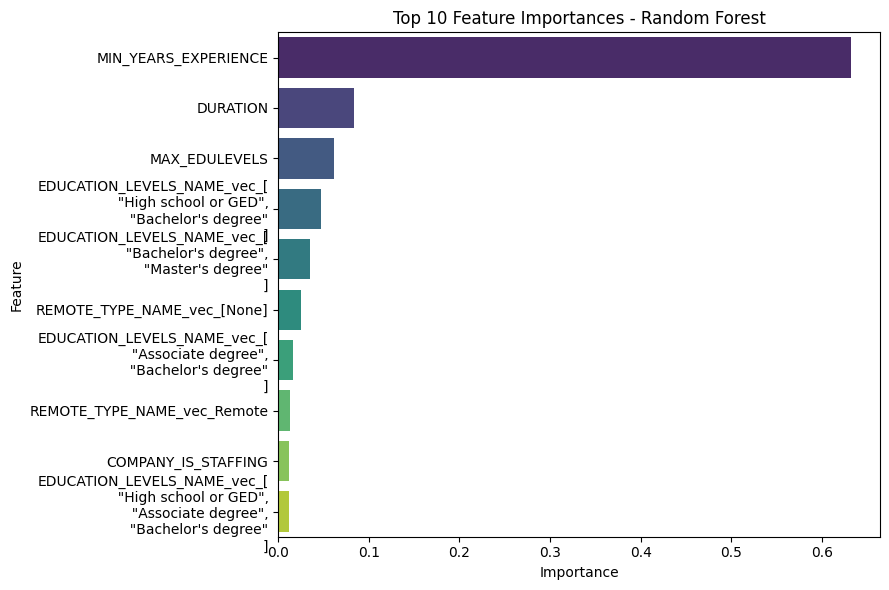

In [41]:
# Pull the actual feature names from the assembled vector's metadata
# This guarantees the names match the importances array length
attrs = prepared.schema["features"].metadata["ml_attr"]["attrs"]
rf_feature_names = []
for kind in ("numeric", "binary", "nominal"):
    if kind in attrs:
        # Sort by index so names line up with the vector positions
        rf_feature_names.extend([a["name"] for a in sorted(attrs[kind], key=lambda x: x["idx"])])

importances = rf_model.featureImportances.toArray()
print("Length of feature names :", len(rf_feature_names))
print("Length of importances   :", len(importances))

imp_df = (pd.DataFrame({"Feature": rf_feature_names, "Importance": importances})
          .sort_values("Importance", ascending=False)
          .head(10))

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, y="Feature", x="Importance", palette="viridis")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.savefig("_output/rf_feature_importance.png", dpi=150)
plt.show()

## 7. Compare 3 Models — GLR, Polynomial, RF

In [42]:
import math

def loglik_aic_bic(model, train_df, label="SALARY"):
    """Compute log-likelihood, AIC, and BIC for a PySpark LinearRegression model."""
    n = train_df.count()
    k = len(model.coefficients) + 1   # +1 for intercept

    # LinearRegression summary exposes RMSE on training data
    rmse_train = model.summary.rootMeanSquaredError
    rss = (rmse_train ** 2) * n
    sigma2 = rss / n   # MLE variance estimate

    log_lik = -0.5 * n * (math.log(2 * math.pi) + math.log(sigma2) + 1)
    aic = 2 * k - 2 * log_lik
    bic = k * math.log(n) - 2 * log_lik
    return log_lik, aic, bic

n_train = train.count()
ll_glr,  aic_glr,  bic_glr  = loglik_aic_bic(glr_model,  train)
ll_poly, aic_poly, bic_poly = loglik_aic_bic(poly_model, train)

# RF doesn't have a likelihood; AIC/BIC don't strictly apply.
results = pd.DataFrame([
    ["LR (Linear)",   rmse,    r2,    aic_glr,  bic_glr],
    ["Polynomial",    rmse_p,  r2_p,  aic_poly, bic_poly],
    ["Random Forest", rmse_rf, r2_rf, np.nan,   np.nan],
], columns=["Model", "RMSE", "R2", "AIC", "BIC"])
results.round(4)

,Model,RMSE,R2,AIC,BIC
0,LR (Linear),31322.4281,0.4367,84288.2021,84486.0261
1,Polynomial,31272.3981,0.4385,84287.7031,84491.7091
2,Random Forest,29434.5905,0.5025,NaN,NaN


In [43]:
def to_pdf(pred_df, model_name):
    pdf = pred_df.select("SALARY", "prediction").toPandas()
    pdf["Model"] = model_name
    return pdf.rename(columns={"prediction": "Predicted"})

all_preds = pd.concat([
    to_pdf(glr_pred,  "GLR"),
    to_pdf(poly_pred, "Polynomial"),
    to_pdf(rf_pred,   "Random Forest"),
], ignore_index=True)

all_preds.head()


,SALARY,Predicted,Model
0,35360,99748.877827,GLR
1,35360,99633.326339,GLR
2,36025,74851.741487,GLR
3,39668,73707.791215,GLR
4,41600,63725.404955,GLR


/tmp/ipykernel_1945/197139595.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="RMSE", palette="mako", ax=ax)


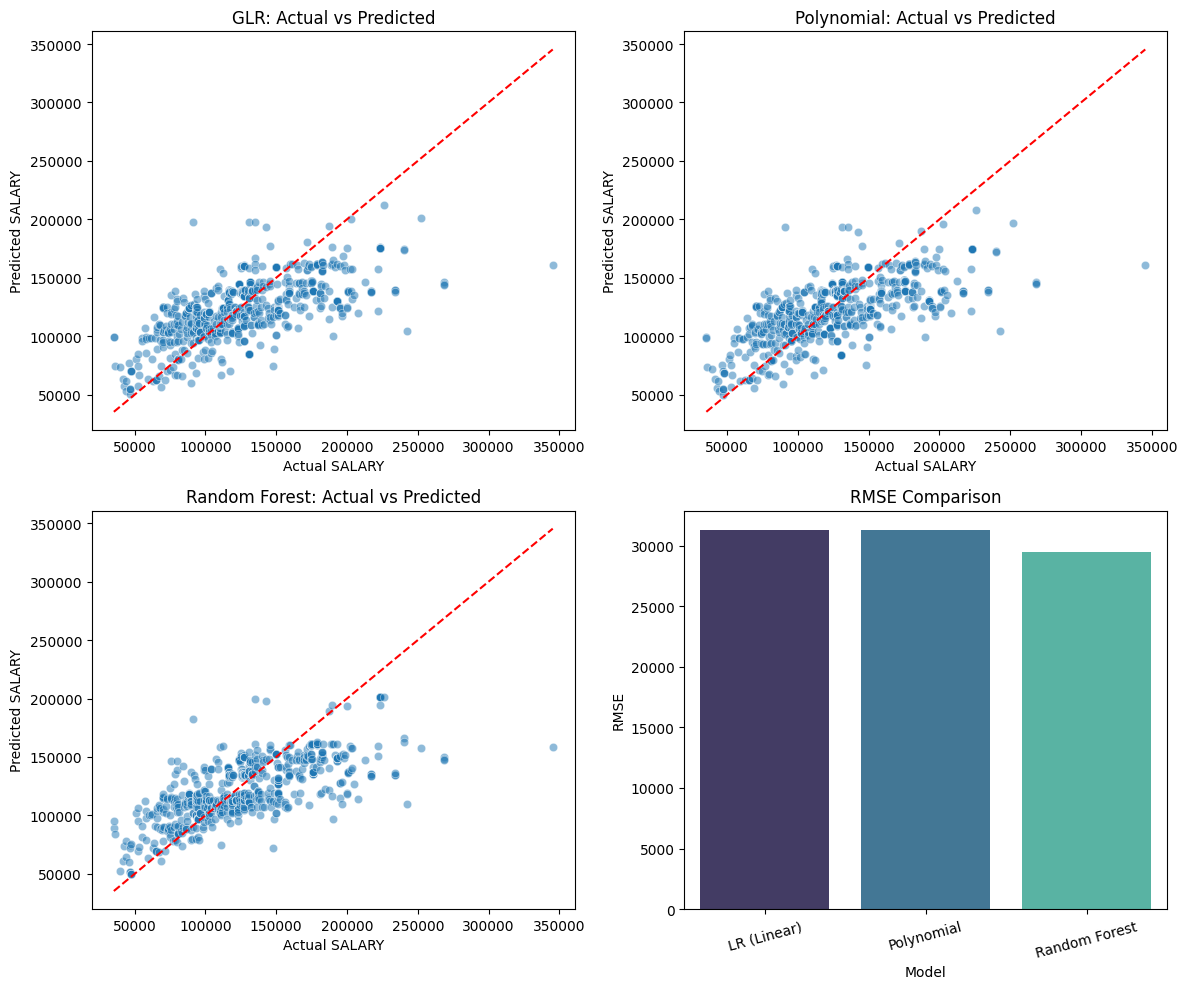

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_list = ["GLR", "Polynomial", "Random Forest"]
positions = [(0,0), (0,1), (1,0)]

for (r, c), m in zip(positions, models_list):
    ax = axes[r][c]
    sub = all_preds[all_preds["Model"] == m]
    sns.scatterplot(data=sub, x="SALARY", y="Predicted", alpha=0.5, ax=ax)
    lo = min(sub["SALARY"].min(), sub["Predicted"].min())
    hi = max(sub["SALARY"].max(), sub["Predicted"].max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)
    ax.set_title(f"{m}: Actual vs Predicted")
    ax.set_xlabel("Actual SALARY")
    ax.set_ylabel("Predicted SALARY")

# Bottom-right: RMSE bar comparison
ax = axes[1][1]
sns.barplot(data=results, x="Model", y="RMSE", palette="mako", ax=ax)
ax.set_title("RMSE Comparison")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("_output/model_comparison.png", dpi=150)
plt.show()


## 7.2 Evaluation Metrics & Model Selection

Comparing the three models on the held-out test set:

| Model | RMSE | R² | AIC | BIC |
|---|---|---|---|---|
| Linear Regression | 31,322 | 0.4367 | 84,288 | 84,486 |
| Polynomial | 31,272 | 0.4385 | 84,288 | 84,492 |
| Random Forest | 29,435 | **0.5025** | — | — |

The **Random Forest is clearly the best performer**, with RMSE ~$1,900 lower and R² nearly 6 points higher than the linear models. This gap is meaningful and reflects RF's ability to capture non-linear interactions between features (most likely between experience level and education category) that the linear models cannot represent. The **Linear and Polynomial models perform almost identically**, RMSE differs by only $50 and R² by 0.002. This matches what we saw in section 5.1, the squared experience term wasn't statistically significant, so adding it didn't meaningfully improve fit. AIC actually drops by 0.5 for the polynomial (essentially a tie), but BIC *increases* by 6 because BIC penalizes the extra parameter more harshly. By the BIC criterion, the simpler linear model is preferred, adding the polynomial term wasn't worth the complexity. 
From my point of view, for prediction, we should use Random Forest. For inference (understanding *which* features matter and by how much), we should keep the linear model, it's interpretable, gives p-values and confidence intervals, and tells the same story about the dominant features (MIN_YEARS_EXPERIENCE, MAX_EDULEVELS, remote status) that the RF feature importance plot confirms.

## 8. Stop Spark

In [ ]:
spark.stop()